In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\neer2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(
C:\Users\neer2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("bank_transactions_data_2.csv")  # read csv file

# Data Analysis

In [3]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [5]:
df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

## EDA

### Boxplot of Transaction Amount

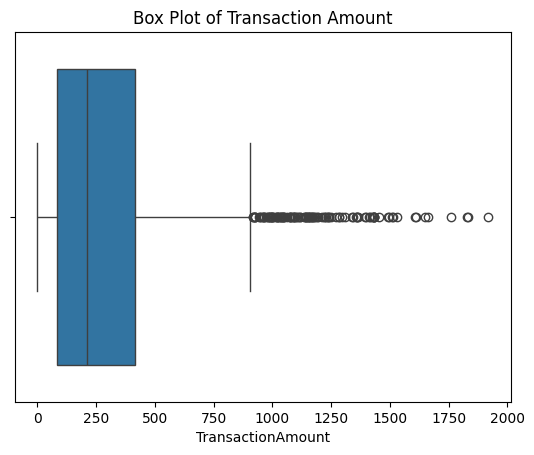

In [6]:
sns.boxplot(x=df['TransactionAmount'])
plt.title("Box Plot of Transaction Amount")
plt.show()

### Scatterplot - Amount against Duration

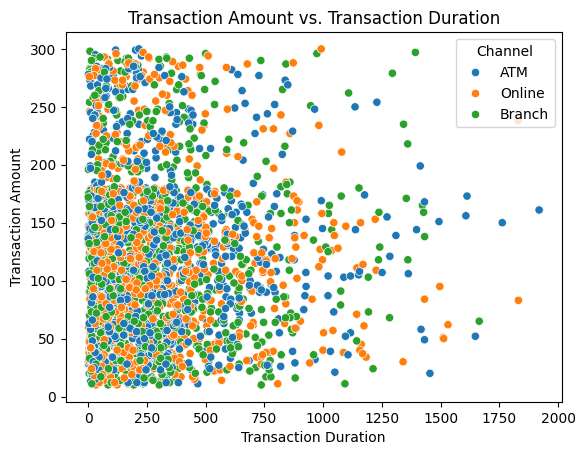

In [7]:
sns.scatterplot(x=df['TransactionAmount'], y=df['TransactionDuration'], hue=df['Channel'])
plt.title('Transaction Amount vs. Transaction Duration')
plt.xlabel('Transaction Duration')
plt.ylabel('Transaction Amount')
plt.show()

In [8]:
print(df[['TransactionAmount', 'TransactionDuration', 'LoginAttempts']].describe())

       TransactionAmount  TransactionDuration  LoginAttempts
count        2512.000000          2512.000000    2512.000000
mean          297.593778           119.643312       1.124602
std           291.946243            69.963757       0.602662
min             0.260000            10.000000       1.000000
25%            81.885000            63.000000       1.000000
50%           211.140000           112.500000       1.000000
75%           414.527500           161.000000       1.000000
max          1919.110000           300.000000       5.000000


### Merchant Influence Information

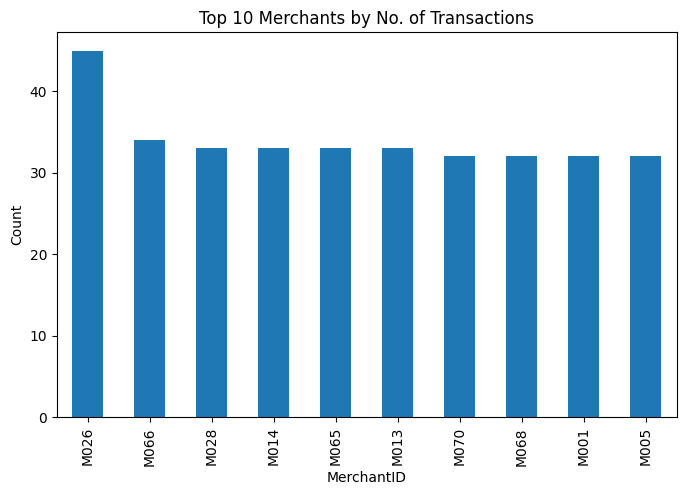

In [9]:
merchant_count = df['MerchantID'].value_counts().head(10)  # top 10 merchants by transaction count

merchant_count.plot(kind='bar', figsize=(8, 5))
plt.title('Top 10 Merchants by No. of Transactions')
plt.xlabel('MerchantID')
plt.ylabel('Count')
plt.show()

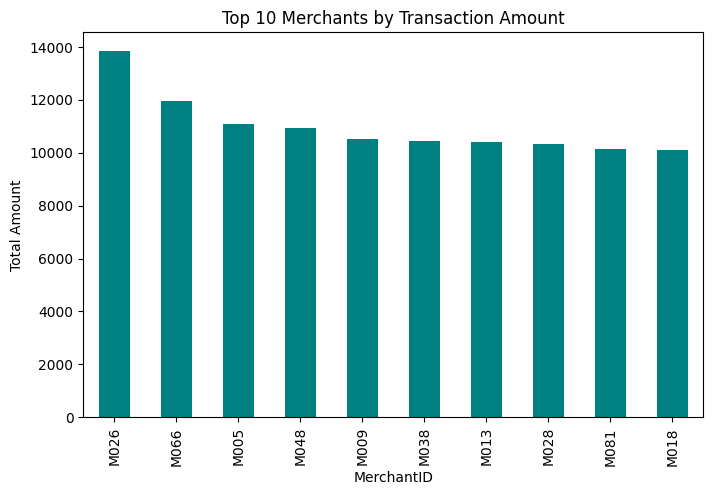

In [10]:
merchant_amount = df.groupby('MerchantID')['TransactionAmount'].sum().sort_values(ascending=False).head(10)  # top 10 merchants by amount

merchant_amount.plot(kind='bar', color='teal', figsize=(8, 5))
plt.title('Top 10 Merchants by Transaction Amount')
plt.xlabel('MerchantID')
plt.ylabel('Total Amount')
plt.show()

# Data Preprocessing

In [11]:
# convert the dates columns to datetime format
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

## Temporal Feature Engineering

In [12]:
df['Hour'] = df['TransactionDate'].dt.hour
df['DayOfWeek'] = df['TransactionDate'].dt.weekday  # Monday = 0, Sunday = 6

df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

## TabTransformer LLM

In [13]:
# define categorical and numerical attributes
categorical = ['AccountID', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerOccupation']
numerical = ['CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']

# encode categorical attributes
label_encoders = {}
for attr in categorical:
    encoder = LabelEncoder()
    df[attr] = encoder.fit_transform(df[attr])
    label_encoders[attr] = encoder  # store encoder for later use

# log-transform transaction amounts
df['TransactionAmount_log'] = np.log1p(df['TransactionAmount'])

# normalise numerical columns
scaler = StandardScaler()
df[numerical] = scaler.fit_transform(df[numerical])

# prepare data for TabTransformer
X = df[categorical + numerical + ['TransactionAmount', 'TransactionAmount_log', 'Hour_sin', 'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos']]
y = (df['TransactionAmount'] > df['TransactionAmount'].mean()).astype(int)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train TabTransformer
clf = TabNetClassifier()
clf.fit(
        X_train.values, y_train.values,
        eval_set=[(X_test.values, y_test.values)],
        eval_metric=['accuracy'],
        max_epochs=500,
        patience=10,
        batch_size=256
    )

# Save the preprocessed data for integration with GNN
X_train.to_csv('X_train_preprocessed.csv', index=False)
X_test.to_csv('X_test_preprocessed.csv', index=False)

C:\Users\neer2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.71894 | val_0_accuracy: 0.54672 |  0:00:00s
epoch 1  | loss: 0.53233 | val_0_accuracy: 0.52485 |  0:00:00s
epoch 2  | loss: 0.36961 | val_0_accuracy: 0.54871 |  0:00:01s
epoch 3  | loss: 0.224   | val_0_accuracy: 0.48111 |  0:00:01s
epoch 4  | loss: 0.13453 | val_0_accuracy: 0.45726 |  0:00:01s
epoch 5  | loss: 0.08966 | val_0_accuracy: 0.46322 |  0:00:02s
epoch 6  | loss: 0.07674 | val_0_accuracy: 0.49503 |  0:00:02s
epoch 7  | loss: 0.05385 | val_0_accuracy: 0.53877 |  0:00:02s
epoch 8  | loss: 0.06625 | val_0_accuracy: 0.62028 |  0:00:02s
epoch 9  | loss: 0.07936 | val_0_accuracy: 0.62624 |  0:00:03s
epoch 10 | loss: 0.08391 | val_0_accuracy: 0.65408 |  0:00:03s
epoch 11 | loss: 0.09257 | val_0_accuracy: 0.666   |  0:00:03s
epoch 12 | loss: 0.07103 | val_0_accuracy: 0.66799 |  0:00:04s
epoch 13 | loss: 0.05716 | val_0_accuracy: 0.69384 |  0:00:04s
epoch 14 | loss: 0.0473  | val_0_accuracy: 0.67793 |  0:00:04s
epoch 15 | loss: 0.05877 | val_0_accuracy: 0.69781 |  0

C:\Users\neer2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


# GNN

In [14]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

## GNN Model Class

Step 1: Define the GNN model

Constrained GAT

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class NodeAnomaly_CGAT(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, heads=4, dropout=0.4):
        super(NodeAnomaly_CGAT, self).__init__()

        # GAT layers to encode node features
        self.gat1 = GATConv(input_dim, hidden_dim, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_dim * heads, output_dim, heads=1, concat=False, dropout=dropout)
        self.gat3 = GATConv(output_dim, output_dim, heads=1, concat=False, dropout=dropout) 
        
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.gat2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.gat3(x, edge_index)  
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        return x  # (num_nodes, output_dim)

In [17]:
class NodeFeatureDecoder(nn.Module):
    def __init__(self, embedding_dim, output_dim):
        super(NodeFeatureDecoder, self).__init__()
        self.decoder = nn.Sequential(
        nn.Linear(embedding_dim, embedding_dim * 2),
        nn.BatchNorm1d(embedding_dim * 2),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(embedding_dim * 2, embedding_dim),
        nn.ReLU(),

        nn.Linear(embedding_dim, output_dim)
    )

    def forward(self, z):
        return self.decoder(z)  # (num_nodes, output_dim)

Edge-level GAT class

In [18]:
from torch_geometric.nn import EdgeConv, GATv2Conv

class EdgeAnomaly_GAT(nn.Module):
    def __init__(self, in_channels, edge_channels):
        super(EdgeAnomaly_GAT, self).__init__()

        # Node encoder (GAT)
        self.node_gnn = GATv2Conv(in_channels, 32)  # Node embeddings

        # Edge encoder (EdgeConv) - learns edge representations
        self.edge_gnn = EdgeConv(nn.Sequential(
            nn.Linear(2 * 32, edge_channels),
            nn.ReLU(),
            nn.Linear(edge_channels, edge_channels)
        ))

    def forward(self, x, edge_index, edge_attr=None):
        x = self.node_gnn(x, edge_index)  # (num_nodes, 32)
        edge_embeddings = self.edge_gnn(x, edge_index)  # (num_edges, edge_channels)

        return edge_embeddings

In [19]:
class InnerProductEdgeDecoder(nn.Module):
    def __init__(self):
        super(InnerProductEdgeDecoder, self).__init__()

    def forward(self, z, edge_index):
        src, dst = edge_index
        z = F.normalize(z, p=2, dim=-1)
        # Inner product between source and destination node embeddings
        edge_logits = (z[src] * z[dst]).sum(dim=1)
        
        return edge_logits

Subgraph-level GAT class

In [20]:
from torch_geometric.nn import SAGPooling, global_mean_pool

class SubgraphAnomaly_EncoderGAT(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, ratio=0.5):
        super(SubgraphAnomaly_EncoderGAT, self).__init__()
        self.gat1 = GATConv(input_dim, hidden_dim, heads=4, dropout=0.4)
        self.gat2 = GATConv(hidden_dim*4, output_dim, heads=1, concat=False, dropout=0.4)
        self.pool = SAGPooling(output_dim, ratio=ratio)
        
    def forward(self, x, edge_index, batch):
        x = self.gat1(x, edge_index)
        x = F.relu(x)
        x = self.gat2(x, edge_index)
        x, edge_index, _, batch, perm, _ = self.pool(x, edge_index, batch=batch)

        # Aggregate node embeddings to create a subgraph embedding
        subgraph_embedding = global_mean_pool(x, batch)  # Mean pooling for subgraph representation
        return subgraph_embedding

In [21]:
class SubgraphFeatureDecoder(nn.Module):
    def __init__(self, embedding_dim, output_dim):
        super(SubgraphFeatureDecoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, output_dim),
            nn.ReLU(),
            nn.Linear(output_dim, output_dim)
        )
    
    def forward(self, z):
        return self.decoder(z)

Combined anomaly detection class

In [22]:
class CombinedGATAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, edge_channels, subgraph_dim):
        super(CombinedGATAutoencoder, self).__init__()

        # Encoders
        self.node_encoder = NodeAnomaly_CGAT(input_dim, hidden_dim, output_dim)  
        self.edge_encoder = EdgeAnomaly_GAT(input_dim, edge_channels)
        self.subgraph_encoder = SubgraphAnomaly_EncoderGAT(input_dim, hidden_dim, subgraph_dim)

        # Decoders
        self.node_decoder = NodeFeatureDecoder(output_dim, input_dim)
        self.edge_decoder = InnerProductEdgeDecoder()
        self.subgraph_decoder = SubgraphFeatureDecoder(subgraph_dim, input_dim)

    def forward(self, x, edge_index, batch, edge_attr=None):
        node_embeddings = self.node_encoder(x, edge_index)
        edge_embeddings = self.edge_encoder(x, edge_index, edge_attr)
        subgraph_embeddings = self.subgraph_encoder(x, edge_index, batch)

        # Reconstruct features
        node_recon = self.node_decoder(node_embeddings)
        edge_recon = self.edge_decoder(node_embeddings, edge_index)

        subgraph_recon = self.subgraph_decoder(subgraph_embeddings)

        return node_recon, edge_recon, subgraph_recon, node_embeddings, edge_embeddings, subgraph_embeddings

In [23]:
from torch_geometric.utils import negative_sampling

def forward_with_neg_sampling(model, data):
    # Forward pass through main autoencoder
    node_recon, edge_embeddings, node_embeddings = model(data.x, data.edge_index, data.edge_attr)

    # Check if edge_embeddings is at least 2D
    if edge_embeddings.dim() == 1:  # If it's 1D, reshape it
        edge_embeddings = edge_embeddings.unsqueeze(-1)  # Ensure it has at least shape [num_edges, 1]

    # Compute edge reconstruction probabilities
    edge_recon = torch.sigmoid(torch.sum(edge_embeddings, dim=1)) 

    # Generate fake edge scores
    edge_recon_neg = torch.zeros_like(edge_recon)  # Dummy negative edge scores for now

    return node_recon, edge_recon, edge_recon_neg

Step 2: Prepare the data

In [24]:
from sklearn.preprocessing import MinMaxScaler

def prepare_data(df):
    # Factorize IDs
    df['source'], _ = pd.factorize(df['AccountID'])
    df['target'], _ = pd.factorize(df['MerchantID'])

    edges = df[['source', 'target']].copy()
    edges['TransactionAmount'] = df['TransactionAmount']

    edge_attr = torch.tensor(edges['TransactionAmount'].values, dtype=torch.float)
    edge_index = torch.tensor(edges[['source', 'target']].values.T, dtype=torch.long)

    # Aggregate node features
    node_features = df.groupby('source').agg({
        'TransactionAmount': ['mean', 'max', 'sum'],
        'AccountBalance': 'mean',
        'Hour_sin': 'mean',
        'Hour_cos': 'mean',
        'DayOfWeek_sin': 'mean',
        'DayOfWeek_cos': 'mean'
    })
    node_features.columns = ['_'.join(col) for col in node_features.columns]

    # Normalize node features here
    scaler = MinMaxScaler()
    node_features_scaled = scaler.fit_transform(node_features)
    x = torch.tensor(node_features_scaled, dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    return data


Step 3: Train the model

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_combined_autoencoder(model, train_loader, optimiser, epochs=200):
    model.train()
    loss_list = []

    for epoch in range(epochs):
        total_loss = 0
        for data in train_loader:
            data = data.to(device)
            optimiser.zero_grad()

            # Forward pass
            node_recon, edge_recon, subgraph_recon, node_embeddings, edge_embeddings, subgraph_embeddings = model(
                data.x, data.edge_index, data.batch, data.edge_attr)

            # Compute node loss
            loss_node = F.mse_loss(node_recon, data.x)
            
            loss_node += 0.001 * torch.norm(node_embeddings, p=2)
            
            # Compute edge loss
            pos_labels = torch.ones(edge_recon.shape[0], dtype=torch.float, device=device)
            loss_edge = F.binary_cross_entropy_with_logits(edge_recon, pos_labels)
            
            # Compute subgraph loss
            subgraph_features = global_mean_pool(data.x, data.batch)
            loss_subgraph = F.mse_loss(subgraph_recon, subgraph_features)
            
            # Combined loss
            total_loss_batch = loss_node + loss_edge + loss_subgraph
            
            # Backpropagation
            total_loss_batch.backward()
            optimiser.step()
            
            total_loss += total_loss_batch.item()
            
            print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
            loss_list.append(total_loss)  
    
    return loss_list

In [26]:
def detect_anomalies_combined(model, test_loader):
    model.eval()
    all_node_scores = []
    all_edge_scores = []

    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)

            # Forward pass
            node_recon, edge_recon, subgraph_recon, node_embeddings, edge_embeddings, subgraph_embeddings = model(
                data.x, data.edge_index, data.batch, data.edge_attr)

            # Node anomaly scores
            node_errors = F.mse_loss(node_recon, data.x, reduction='none').mean(dim=1).cpu().numpy()
            all_node_scores.extend(node_errors.tolist())

            # Edge anomaly scores
            edge_probs = torch.sigmoid(edge_recon)  # Convert logits to probabilities
            pos_labels = torch.ones(edge_probs.shape[0], dtype=torch.float, device=device)
            loss_edge = F.binary_cross_entropy(edge_probs, pos_labels)

            # Calculate edge anomaly scores: Anomalous if probability is low
            edge_errors = (1.0 - edge_probs).cpu().numpy()
            all_edge_scores.extend(edge_errors.tolist())

            print(f"Edge Reconstruction Scores (Logits): {edge_recon[:10].cpu().numpy()}")
            print(f"Edge Probabilities: {edge_probs[:10].cpu().numpy()}")
            print(f"Edge Errors (Anomaly Scores): {edge_errors[:10]}")

    return all_node_scores, all_edge_scores

In [27]:
def detect_subgraph_anomalies(model, test_loader):
    model.eval()
    all_subgraph_scores = []

    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)

            # Forward pass
            node_recon, edge_recon, subgraph_recon, _, _, subgraph_embeddings = model(data.x, data.edge_index, data.batch, data.edge_attr)

            # Subgraph anomaly scores
            subgraph_errors = F.mse_loss(subgraph_recon, data.x, reduction='none').mean(dim=1).cpu().numpy()
            all_subgraph_scores.extend(subgraph_errors.tolist())

    return all_subgraph_scores

Step 4: Compute anomaly scores

In [28]:
def compute_anomaly_scores(model, data_loader):
    model.eval()
    anomaly_scores = []
    for data in data_loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr)  # Get output embeddings
        scores = torch.sum((out - out.mean(dim=0))**2, dim=1)  # Anomaly score = L2 distance from mean
        anomaly_scores.append(scores.cpu())
    return torch.cat(anomaly_scores)

Step 5: Visualise anomalies

In [29]:
def visualize_anomalies(data, anomaly_scores, top_k=10):
    # Get top-K anomalies
    top_k_indices = torch.topk(anomaly_scores, k=top_k).indices
    print("Top Anomalies (Node Indices):", top_k_indices.tolist())
    print("Anomaly Scores:", anomaly_scores[top_k_indices].tolist())

    # Convert graph to NetworkX
    G = to_networkx(data, to_undirected=True)
    node_colors = ['red' if i in top_k_indices else 'blue' for i in range(data.num_nodes)]

    # Plot graph
    plt.figure(figsize=(12, 8))
    nx.draw(G, node_color=node_colors, with_labels=True)
    plt.title("Graph with Anomalies (Red = Anomalous, Blue = Normal)")
    plt.show()
    
    return top_k_indices.tolist()

## Training data

In [30]:
import torch.optim as optim

# Load the dataset (modify according to your file structure)
train_df = pd.read_csv("X_train_preprocessed.csv")
test_df = pd.read_csv("X_test_preprocessed.csv")

# Step 1: Define relationships and features in prepare_data
train_data = prepare_data(train_df)
test_data = prepare_data(test_df)

# Step 2: Create DataLoaders
train_loader = DataLoader([train_data], batch_size=1, shuffle=True)
test_loader = DataLoader([test_data], batch_size=1, shuffle=False)

# Step 3: Define GNN model and optimiser
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instantiate model
model = CombinedGATAutoencoder(
    input_dim=train_data.num_node_features, 
    hidden_dim=32, 
    output_dim=16, 
    edge_channels=8,
    subgraph_dim=16
).to(device)


# Optimiser
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

# Train model
loss_list = train_combined_autoencoder(model, train_loader, optimiser, epochs=200)

# Detect anomalies on test set
node_anomalies, edge_anomalies = detect_anomalies_combined(model, test_loader)

# Show Top anomalies
top_nodes = sorted(enumerate(node_anomalies), key=lambda x: x[1], reverse=True)[:20]
top_edges = sorted(enumerate(edge_anomalies), key=lambda x: x[1], reverse=True)[:20]

print("Top Node Anomalies:")
for idx, score in top_nodes:
    print(f"Node {idx}, Score: {score:.4f}")

print("\nTop Edge Anomalies:")
for idx, score in top_edges:
    print(f"Edge {idx}, Score: {score:.4f}")

Epoch 1, Loss: 1.1873
Epoch 2, Loss: 1.0700
Epoch 3, Loss: 1.0506
Epoch 4, Loss: 1.0288
Epoch 5, Loss: 1.0114
Epoch 6, Loss: 0.9915
Epoch 7, Loss: 0.9780
Epoch 8, Loss: 0.9758
Epoch 9, Loss: 0.9735
Epoch 10, Loss: 0.9493
Epoch 11, Loss: 0.9463
Epoch 12, Loss: 0.9183
Epoch 13, Loss: 0.9181
Epoch 14, Loss: 0.8989
Epoch 15, Loss: 0.8965
Epoch 16, Loss: 0.8713
Epoch 17, Loss: 0.8624
Epoch 18, Loss: 0.8524
Epoch 19, Loss: 0.8387
Epoch 20, Loss: 0.8173
Epoch 21, Loss: 0.8309
Epoch 22, Loss: 0.8127
Epoch 23, Loss: 0.7976
Epoch 24, Loss: 0.7803
Epoch 25, Loss: 0.7724
Epoch 26, Loss: 0.7609
Epoch 27, Loss: 0.7636
Epoch 28, Loss: 0.7469
Epoch 29, Loss: 0.7345
Epoch 30, Loss: 0.7266
Epoch 31, Loss: 0.7182
Epoch 32, Loss: 0.7165
Epoch 33, Loss: 0.7076
Epoch 34, Loss: 0.6914
Epoch 35, Loss: 0.6827
Epoch 36, Loss: 0.6877
Epoch 37, Loss: 0.6618
Epoch 38, Loss: 0.6694
Epoch 39, Loss: 0.6442
Epoch 40, Loss: 0.6539
Epoch 41, Loss: 0.6501
Epoch 42, Loss: 0.6401
Epoch 43, Loss: 0.6373
Epoch 44, Loss: 0.63

### Graph of loss

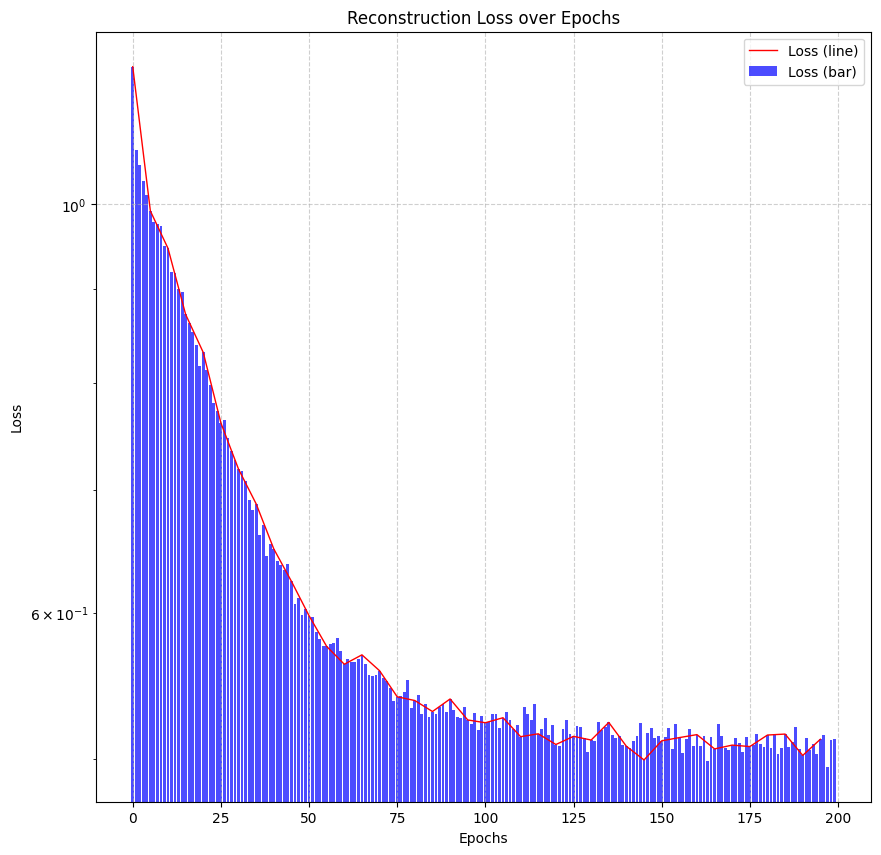

In [31]:
epochs = 200
plt.figure(figsize=(10,10))
plt.bar(range(epochs), loss_list, color='blue', alpha=0.7, label='Loss (bar)')
plt.plot(range(epochs)[::5], loss_list[::5], color='red', linestyle='-', linewidth=1, label='Loss (line)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.yscale('log')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Reconstruction Loss over Epochs")
plt.legend()
plt.show()

## Model Testing

## Model Evaluation

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.spatial.distance import mahalanobis

Silhouette Score & Calinski-Harabasz Score

In [33]:
model.eval()

data = next(iter(test_loader)).to(device)

with torch.no_grad():
    # Forward pass and unpacking
    node_recon, edge_recon, subgraph_recon, node_embeddings, edge_embeddings, subgraph_embeddings = model(
        data.x, data.edge_index, data.batch, data.edge_attr
    )

# Convert embeddings to numpy
node_embeddings_np = node_embeddings.cpu().numpy()

# Apply KMeans Clustering (assuming 2 clusters: normal vs anomaly)
kmeans = KMeans(n_clusters=2, random_state=0).fit(node_embeddings_np)
cluster_labels = kmeans.labels_

# Compute Silhouette Score (higher is better, max = 1)
sil_score = silhouette_score(node_embeddings_np, cluster_labels)

# Compute Calinski-Harabasz Score (higher is better)
ch_score = calinski_harabasz_score(node_embeddings_np, cluster_labels)

print(f"Silhouette Score: {sil_score:.4f}")
print(f"Calinski-Harabasz Score: {ch_score:.4f}")

Silhouette Score: 0.8672
Calinski-Harabasz Score: 1102.8740


Mahalanobis Distance

In [34]:
from numpy.linalg import inv

def compute_mahalanobis_distance(node_embeddings):
    node_anomalies_np = node_embeddings.cpu().numpy()
    
    mean_vector = np.mean(node_embeddings_np, axis=0)
    cov_matrix = np.cov(node_anomalies_np, rowvar=False)
    
    inv_cov_matrix = inv(cov_matrix + np.eye(cov_matrix.shape[0]) * 1e-6)
    
    mahalanobis_distance = np.array([mahalanobis(node, mean_vector, inv_cov_matrix) for node in node_embeddings_np])
    
    mahalanobis_distance = (mahalanobis_distance - mahalanobis_distance.min()) / (mahalanobis_distance.max() - mahalanobis_distance.min())
    
    return mahalanobis_distance

In [35]:
def compare_anomalies(model_anomalies, mahalanobis_anomalies, mahalanobis_distances):

    # Extract node indices detected by the model
    model_anomaly_nodes = {node for node, _ in model_anomalies}

    # Extract nodes detected by Mahalanobis distance
    mahalanobis_anomaly_nodes = set(mahalanobis_anomalies)

    # Find common anomalies
    common_anomalies = model_anomaly_nodes.intersection(mahalanobis_anomaly_nodes)

    # Store results
    results = []
    print("\nNodes Detected as Anomalies by BOTH Model & Mahalanobis Distance:")
    for node in sorted(common_anomalies):
        model_score = next(score for n, score in model_anomalies if n == node)
        mahalanobis_score = mahalanobis_distances[node]
        results.append((node, model_score, mahalanobis_score))
        print(f"Node {node} - Model Score: {model_score:.4f}, Mahalanobis Distance: {mahalanobis_score:.4f}")

    return results

In [36]:
# Ensure model is in evaluation mode
model.eval()

# Get a batch of test data
data = next(iter(test_loader)).to(device)

with torch.no_grad():
    node_recon, edge_recon, subgraph_recon, node_embeddings, edge_embeddings, subgraph_embeddings = model(
    data.x, data.edge_index, data.batch, data.edge_attr
)


# Compute Mahalanobis Distances
mahalanobis_distances = compute_mahalanobis_distance(node_embeddings)

# Sort nodes by highest Mahalanobis distance
top_mahalanobis_anomalies = np.argsort(mahalanobis_distances)[-20:]  # Top 20 anomalous nodes

# Compare with model's anomaly detection output
print("\nTop Nodes by Model Anomaly Score:")
for i, (node, score) in enumerate(top_nodes):  # Assuming `top_nodes` holds model-ranked anomalies
    print(f"Rank {i+1}: Node {node}, Model Score: {score:.4f}, Mahalanobis Distance: {mahalanobis_distances[node]:.4f}")

print("\nTop Nodes by Mahalanobis Distance:")
for i, node in enumerate(top_mahalanobis_anomalies):
    print(f"Rank {i+1}: Node {node}, Mahalanobis Distance: {mahalanobis_distances[node]:.4f}, Model Score: {node_anomalies[node]:.4f}")


Top Nodes by Model Anomaly Score:
Rank 1: Node 115, Model Score: 0.2438, Mahalanobis Distance: 1.0000
Rank 2: Node 52, Model Score: 0.2241, Mahalanobis Distance: 0.0495
Rank 3: Node 116, Model Score: 0.2164, Mahalanobis Distance: 0.0551
Rank 4: Node 174, Model Score: 0.2151, Mahalanobis Distance: 0.8468
Rank 5: Node 111, Model Score: 0.2150, Mahalanobis Distance: 0.0551
Rank 6: Node 263, Model Score: 0.2146, Mahalanobis Distance: 0.8402
Rank 7: Node 62, Model Score: 0.2141, Mahalanobis Distance: 0.0551
Rank 8: Node 217, Model Score: 0.2127, Mahalanobis Distance: 0.8246
Rank 9: Node 224, Model Score: 0.2118, Mahalanobis Distance: 0.0551
Rank 10: Node 236, Model Score: 0.2101, Mahalanobis Distance: 0.7584
Rank 11: Node 239, Model Score: 0.2098, Mahalanobis Distance: 0.0551
Rank 12: Node 241, Model Score: 0.2086, Mahalanobis Distance: 0.7149
Rank 13: Node 251, Model Score: 0.2051, Mahalanobis Distance: 0.0551
Rank 14: Node 151, Model Score: 0.1917, Mahalanobis Distance: 0.0551
Rank 15: N

In [37]:
# Step 1: Compute Model-based Anomalies (Top 20 nodes)
top_nodes = sorted(enumerate(node_anomalies), key=lambda x: x[1], reverse=True)[:20]

# Step 2: Compute Mahalanobis-based Anomalies (Top 20 nodes)
top_mahalanobis_anomalies = np.argsort(mahalanobis_distances)[-20:]  # Get indices of top 20 anomalous nodes

# Step 3: Call Comparison Function
common_anomalies = compare_anomalies(top_nodes, top_mahalanobis_anomalies, mahalanobis_distances)


Nodes Detected as Anomalies by BOTH Model & Mahalanobis Distance:
Node 115 - Model Score: 0.2438, Mahalanobis Distance: 1.0000
Node 174 - Model Score: 0.2151, Mahalanobis Distance: 0.8468
Node 196 - Model Score: 0.1833, Mahalanobis Distance: 0.5192
Node 217 - Model Score: 0.2127, Mahalanobis Distance: 0.8246
Node 236 - Model Score: 0.2101, Mahalanobis Distance: 0.7584
Node 241 - Model Score: 0.2086, Mahalanobis Distance: 0.7149
Node 254 - Model Score: 0.1891, Mahalanobis Distance: 0.5249
Node 263 - Model Score: 0.2146, Mahalanobis Distance: 0.8402


## Explainability & Interpretability

In [38]:
class NodeReconWrapper(torch.nn.Module):
    def __init__(self, base_model, original_x):
        super().__init__()
        self.base_model = base_model
        self.original_x = original_x  # reference features for reconstruction comparison

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        node_recon, _, _, _, _, _ = self.base_model(x, edge_index, batch=batch, edge_attr=edge_attr)
        
        # Return per-node L2 reconstruction error as a 1D tensor
        error = torch.norm(node_recon - self.original_x, p=2, dim=1)  # shape: [num_nodes]
        return error

In [39]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer
from torch_geometric.explain.config import ModelConfig
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
import torch.nn.functional as F
import torch_scatter
import torch

model.eval()

wrapped_model = NodeReconWrapper(model, original_x=data.x)

explainer = Explainer(
    model=wrapped_model,
    algorithm=GNNExplainer(epochs=500, lr=0.005),  # Adjust epochs and lr for better convergence
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=ModelConfig(
        mode='binary_classification',
        task_level='node',
        return_type='raw'
    )
)

# Store explanations
explanations = {}

for i, (node_idx, model_score) in enumerate(top_nodes):
    print(f"Explaining node {node_idx} (Rank {i+1})...")
    
    explanation = explainer(
        x=data.x,
        edge_index=data.edge_index,
        edge_attr=getattr(data, "edge_attr", None),
        index=node_idx,
        batch=data.batch
    )

    explanations[node_idx] = explanation

Explaining node 115 (Rank 1)...
Explaining node 52 (Rank 2)...
Explaining node 116 (Rank 3)...
Explaining node 174 (Rank 4)...
Explaining node 111 (Rank 5)...
Explaining node 263 (Rank 6)...
Explaining node 62 (Rank 7)...
Explaining node 217 (Rank 8)...
Explaining node 224 (Rank 9)...
Explaining node 236 (Rank 10)...
Explaining node 239 (Rank 11)...
Explaining node 241 (Rank 12)...
Explaining node 251 (Rank 13)...
Explaining node 151 (Rank 14)...
Explaining node 276 (Rank 15)...
Explaining node 205 (Rank 16)...
Explaining node 152 (Rank 17)...
Explaining node 254 (Rank 18)...
Explaining node 30 (Rank 19)...
Explaining node 196 (Rank 20)...


In [40]:
def generate_detailed_summary(explanation, node_idx, feature_names=None, top_k=3):
    feat_mask = explanation.node_mask.cpu().detach().numpy()
    if feat_mask.ndim > 1:
        feat_mask = feat_mask[node_idx]
    top_feats = feat_mask.argsort()[-top_k:][::-1]
    summary = []
    for i in top_feats:
        name = f"Feature {i}" if feature_names is None else feature_names[i]
        score = feat_mask[i]
        summary.append(f"{name} ({score:.2f})")
    return f"Node {node_idx} influenced by: {', '.join(summary)}."

In [41]:
def generate_combined_contextual_explanations(model, data, top_k=20, alpha=0.4, beta=0.3, gamma=0.3):
    model.eval()
    with torch.no_grad():
        node_recon, edge_recon, subgraph_recon, node_emb, edge_emb, subgraph_emb = model(
            data.x, data.edge_index, data.batch, data.edge_attr
        )

        # Compute individual components
        node_score = F.mse_loss(node_recon, data.x, reduction='none').mean(dim=1)
        edge_probs = torch.sigmoid(edge_recon)
        edge_score = 1.0 - edge_probs
        node_edge_score = torch_scatter.scatter_mean(edge_score, data.edge_index[0], dim=0, dim_size=data.num_nodes)

        pooled_subgraph_x = torch_scatter.scatter_mean(data.x, data.batch, dim=0)
        subgraph_score = F.mse_loss(subgraph_recon, pooled_subgraph_x, reduction='none').mean(dim=1)
        node_subgraph_score = subgraph_score[data.batch]

        # Combine scores
        final_score = alpha * node_score + beta * node_edge_score + gamma * node_subgraph_score
        final_score = (final_score - final_score.min()) / (final_score.max() - final_score.min())
        top_indices = torch.topk(final_score, top_k).indices

    # Set up the explainer
    wrapped_model = NodeReconWrapper(model, original_x=data.x)
    explainer = Explainer(
        model=wrapped_model,
        algorithm=GNNExplainer(epochs=500, lr=0.005),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=ModelConfig(
            mode='binary_classification',
            task_level='node',
            return_type='raw'
        )
    )

    feature_names = [
        "TransactionAmount_mean",
        "TransactionAmount_max",
        "TransactionAmount_sum",
        "AccountBalance_mean",
        "Hour_sin_mean",
        "Hour_cos_mean",
        "DayOfWeek_sin_mean",
        "DayOfWeek_cos_mean"
    ]

    combined_explanations = []

    for i, node_idx in enumerate(top_indices):
        explanation = explainer(
            x=data.x,
            edge_index=data.edge_index,
            edge_attr=getattr(data, "edge_attr", None),
            index=int(node_idx),
            batch=data.batch
        )
        summary = generate_detailed_summary(explanation, int(node_idx), feature_names=feature_names)
        combined_explanations.append({
            "Rank": i + 1,
            "Node": int(node_idx),
            "Final Score": float(final_score[node_idx]),
            "Node Score": float(node_score[node_idx]),
            "Edge Influence": float(node_edge_score[node_idx]),
            "Subgraph Influence": float(node_subgraph_score[node_idx]),
            "Explanation": summary
        })

    return pd.DataFrame(combined_explanations)

In [42]:
# Run the function
df_combined_explanations = generate_combined_contextual_explanations(model, data, top_k=20)

# Save or display
df_combined_explanations.to_csv("top_contextual_anomalies_with_explanations.csv", index=False)